In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA SETUP ---
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# Cleaning: Fix decimal commas and strip strings
cols_to_fix = ['Infant mortality (per 1000 births)', 'Birthrate', 'Phones (per 1000)', 'Service', 'Area (sq. mi.)', 'Population']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
df['Region'] = df['Region'].str.strip()

In [ ]:
# problem 1
# Հայերեն: Օգտագործեք NumPy-ը՝ հաշվելու 'Infant mortality (per 1000 births)'-ի 10-րդ պերցենտիլը:
print(np.percentile(df["Infant mortality (per 1000 births)"].dropna(),10))

4.768


In [46]:
# problem 2
# Հայերեն: Ստեղծեք նոր 'Birth_Category' սյունակ՝ օգտագործելով np.where: 
# Եթե 'Birthrate' > 30, նշեք 'High', հակառակ դեպքում՝ 'Normal':
df["Birth_Category"]=np.where(df["Birthrate"]>30,"High","Normal")
print(df["Birth_Category"])

0        High
1      Normal
2      Normal
3      Normal
4      Normal
        ...  
222      High
223    Normal
224      High
225      High
226    Normal
Name: Birth_Category, Length: 227, dtype: str


In [ ]:
# problem 3
# Հայերեն: Զտեք այն երկրները 'SUB-SAHARAN AFRICA' տարածաշրջանում, որոնք ունեն 100-ից ավել 'Phones (per 1000)':
more_100=df[(df["Region"]=="SUB-SAHARAN AFRICA") & (df["Phones (per 1000)"]>100)]
print(more_100["Country"])

37       Cape Verde 
133       Mauritius 
167         Reunion 
171    Saint Helena 
182      Seychelles 
189    South Africa 
Name: Country, dtype: str


In [ ]:
# problem 4
# Հայերեն: Խմբավորեք ըստ 'Region'-ի և հաշվեք յուրաքանչյուր տարածաշրջանի 'Service' (տնտեսական ոլորտ) միջինը:
grouped=df.groupby("Region")["Service"].mean()
print(grouped)

Region
ASIA (EX. NEAR EAST)    0.520107
BALTICS                 0.661667
C.W. OF IND. STATES     0.480167
EASTERN EUROPE          0.598667
LATIN AMER. & CARIB     0.650721
NEAR EAST               0.530000
NORTHERN AFRICA         0.432000
NORTHERN AMERICA        0.787000
OCEANIA                 0.608938
SUB-SAHARAN AFRICA      0.449755
WESTERN EUROPE          0.714625
Name: Service, dtype: float64


Text(100000000, 9000000000, 'China')

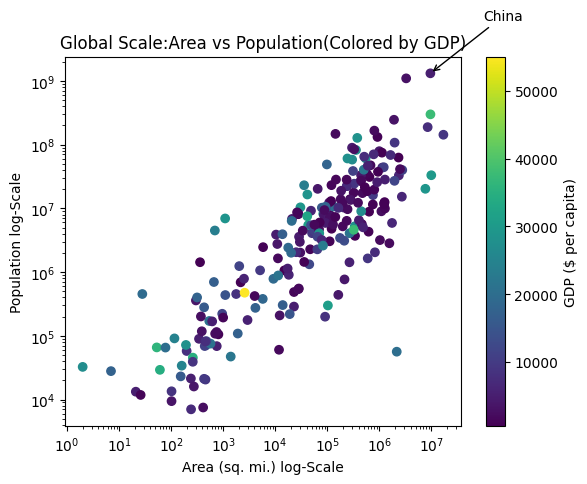

In [ ]:
# probelm 5
# Հայերեն: Ստեղծեք 'Area (sq. mi.)'-ի և 'Population'-ի scatter plot:
# 1. Օգտագործեք լոգարիթմական սանդղակներ երկու առանցքների համար:
# 2. Գունավորեք կետերը ըստ 'GDP ($ per capita)'-ի:
# 3. Օգտագործեք plt.annotate՝ «China»-ն պիտակավորելու համար:
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Area (sq. mi.) log-Scale")
plt.ylabel("Population log-Scale")
plt.title("Global Scale:Area vs Population(Colored by GDP)")
plt.scatter(df["Area (sq. mi.)"],df["Population"],c=df["GDP ($ per capita)"])
plt.colorbar(label="GDP ($ per capita)")
china=df[df['Country'].str.contains('China')]
plt.annotate("China",
          xy=(china["Area (sq. mi.)"].values[0],
              china["Population"].values[0]),
        xytext=(100000000,9000000000),
        arrowprops=dict(arrowstyle="->")
)